Channel             0
Region              0
Fresh               0
Milk                0
Grocery             0
Frozen              0
Detergents_Paper    0
Delicassen          0
dtype: int64
[[ 1.44865163  0.59066829  0.05293319  0.52356777 -0.04111489 -0.58936716
  -0.04356873 -0.06633906]
 [ 1.44865163  0.59066829 -0.39130197  0.54445767  0.17031835 -0.27013618
   0.08640684  0.08915105]
 [ 1.44865163  0.59066829 -0.44702926  0.40853771 -0.0281571  -0.13753572
   0.13323164  2.24329255]
 [-0.69029709  0.59066829  0.10011141 -0.62401993 -0.3929769   0.6871443
  -0.49858822  0.09341105]
 [ 1.44865163  0.59066829  0.84023948 -0.05239645 -0.07935618  0.17385884
  -0.23191782  1.29934689]]


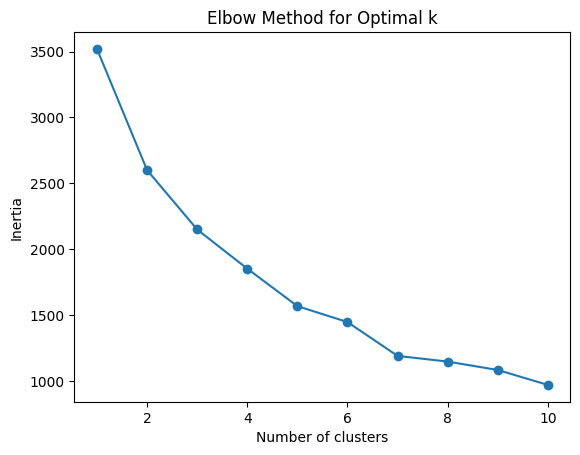

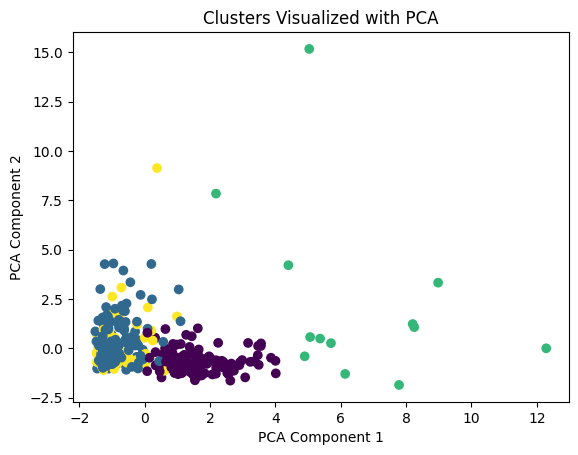

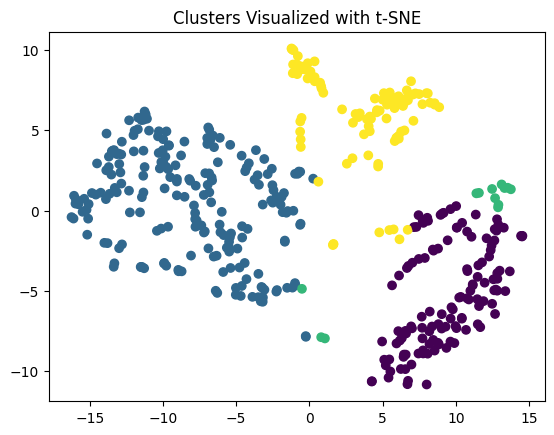

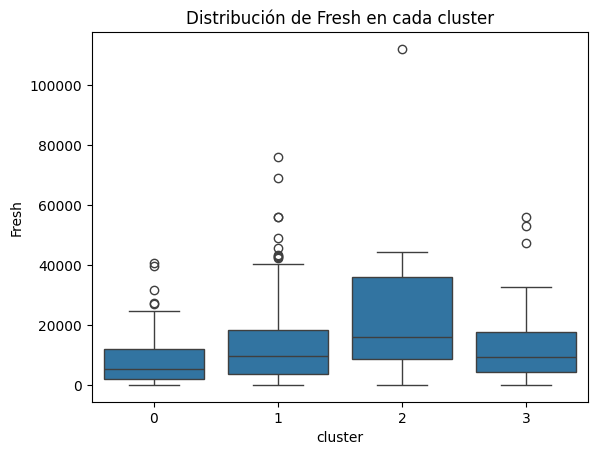

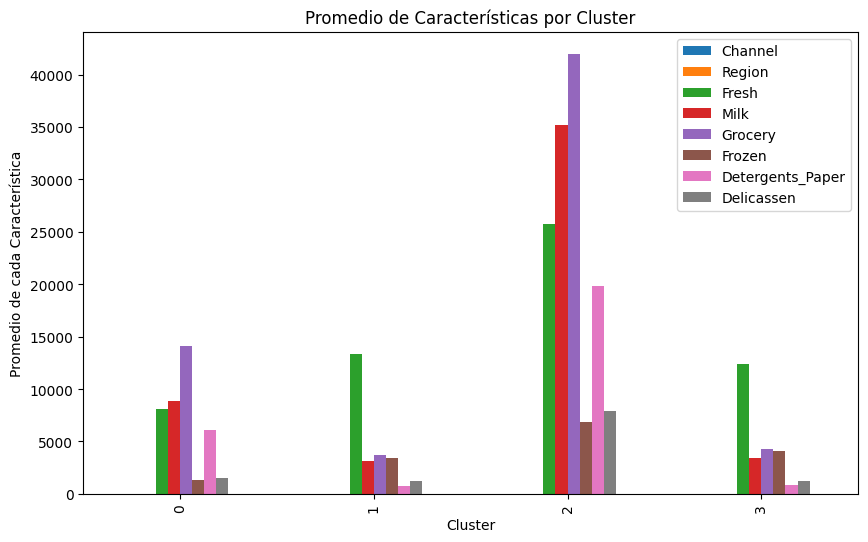

In [3]:
# Importación de bibliotecas necesarias
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns

# Cargar el dataset usando una ruta absoluta
data = pd.read_csv('dataset.csv')

# Visualizar las primeras filas del dataset
data.head()

# Preprocesamiento de los datos
# Verificar si existen valores nulos
print(data.isnull().sum())

# Escalar los datos utilizando StandardScaler
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data)

# Verificar los primeros valores escalados
print(data_scaled[:5])

# Aplicar el Método del Codo para determinar el número óptimo de clusters
inertia = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(data_scaled)
    inertia.append(kmeans.inertia_)

# Graficar el Método del Codo
plt.plot(range(1, 11), inertia, marker='o')
plt.title('Elbow Method for Optimal k')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.show()

# Definir el número óptimo de clusters (por ejemplo, 4 según el Método del Codo)
kmeans = KMeans(n_clusters=4, random_state=42)
kmeans.fit(data_scaled)

# Asignar los clusters a cada cliente
data['cluster'] = kmeans.labels_

# Visualizar las primeras filas con la asignación de clusters
data.head()

# Visualización de los resultados
# Gráfico de Clusters en 2D utilizando PCA
pca = PCA(n_components=2, random_state=42)
pca_data = pca.fit_transform(data_scaled)

# Graficar los clusters en un gráfico 2D
plt.scatter(pca_data[:, 0], pca_data[:, 1], c=data['cluster'], cmap='viridis')
plt.title('Clusters Visualized with PCA')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.show()

# Gráfico de Clusters en 2D utilizando t-SNE
tsne = TSNE(n_components=2, perplexity=30, max_iter=300, random_state=42)
tsne_data = tsne.fit_transform(data_scaled)

# Graficar los clusters en un gráfico 2D con t-SNE
plt.scatter(tsne_data[:, 0], tsne_data[:, 1], c=data['cluster'], cmap='viridis')
plt.title('Clusters Visualized with t-SNE')
plt.show()

# Crear boxplots para una característica específica, por ejemplo, 'Fresh'
sns.boxplot(x='cluster', y='Fresh', data=data)
plt.title('Distribución de Fresh en cada cluster')
plt.show()

# Graficar la media de las características por cada cluster
data.groupby('cluster').mean().plot(kind='bar', figsize=(10, 6))
plt.title('Promedio de Características por Cluster')
plt.xlabel('Cluster')
plt.ylabel('Promedio de cada Característica')
plt.show()
